### 02 The Canonical Metalens Pipeline

A reference-grade walkthrough of the five stages of metalens design.
Each stage shows: what's happening physically, the call signature, the
artifact it produces, and a focused visualization.

**Stages**
1. Domain types & runtime composition
2. Material selection
3. RCWA meta-atom sweep
4. Phase profile + quantization
5. Focal-plane analysis (PSF, MTF, Strehl, Zernike)
6. (Optional) GDS export

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

### 1 Domain types

Pydantic-validated containers describe the design. The model enforces
physical sanity (e.g. `max_diameter_nm < periodicity_nm - 20`).

In [2]:
from metaopticsai.domain.design import MetalensDesignParams

params = MetalensDesignParams(
    wavelength_nm=532,
    focal_length_mm=0.1,
    diameter_mm=0.05,
    pillar_material="TiO2",
    pillar_height_nm=600.0,
    periodicity_nm=350.0,
    min_diameter_nm=50.0,
    max_diameter_nm=250.0,
)
print(f"NA:          {params.numerical_aperture:.3f}")
print(f"f-number:    {params.f_number:.3f}")
print(f"Mean pillar Ø: {params.mean_diameter_nm:.0f} nm")
print(f"Aspect ratio:  {params.aspect_ratio:.2f}")

NA:          0.243
f-number:    2.000
Mean pillar Ø: 150 nm
Aspect ratio:  4.00


### 2 Runtime composition

The store + backends + tools triangle is the only required setup.

In [3]:
from metaopticsai.store.memory import InMemoryArtifactStore
from metaopticsai.physics.backends.base import BackendRegistry
from metaopticsai.physics.backends.analytical import AnalyticalBackend
from metaopticsai.tools import build_tool_registry

store = InMemoryArtifactStore()
backends = BackendRegistry()
backends.register(AnalyticalBackend())
tools = build_tool_registry(store, backends)

### **3 Material lookup**

`list_materials` returns every refractive-index CSV; `get_material_index`
interpolates n + ik at a target wavelength.

> **Note**: both tools read CSVs from `vendor/metabox3/material_data/`.
> If you haven't vendored metabox3 yet, the cell below falls back
> gracefully to a built-in default.

In [4]:
try:
    ti_o2 = tools.get("get_material_index").call_sync({
        "name": "TiO2", "wavelength_nm": 532
    })
    print(f"TiO2 @ 532 nm: n = {ti_o2['n']:.4f}, k = {ti_o2['k']:.4f}")
    print(f"Valid range: {ti_o2['valid_range_um']} µm")
except Exception as e:
    print(f"Material lookup unavailable ({type(e).__name__}): {e}")
    print("Falling back to typical TiO2 @ 532 nm: n ≈ 2.35, k ≈ 0.")

Material lookup unavailable (ModuleNotFoundError): No module named 'src'
Falling back to typical TiO2 @ 532 nm: n ≈ 2.35, k ≈ 0.


d:\metacode\src\metaopticsai\vendor\metabox3\__init__.py:13: UserWarning: vendor.metabox3 not populated yet (No module named 'src'); copy your metabox3/ directory into src/metaopticsai/vendor/metabox3/.
  warnings.warn(


### 4 · RCWA sweep

We sweep pillar diameter to enumerate a **phase library** — the LUT we'll
consult when mapping a continuous phase profile onto discrete meta-atoms.

In [5]:
sweep = tools.get("run_rcwa_sweep").call_sync({
    "wavelength_nm": params.wavelength_nm,
    "pillar_material": params.pillar_material,
    "pillar_height_nm": params.pillar_height_nm,
    "period_nm": params.periodicity_nm,
    "min_diameter_nm": params.min_diameter_nm,
    "max_diameter_nm": params.max_diameter_nm,
    "n_samples": 40,
    "xy_harmonics": 5,
})
for k, v in sweep.items():
    if k != "handle":
        print(f"  {k}: {v}")

  phase_coverage_2pi_fraction: 0.7016461739372571
  mean_transmission: 0.9956744186046512
  elapsed_s: 0.0
  n_samples: 40
  backend: analytical
  advice: Phase coverage < 0.9 — increase pillar_height_nm or widen the diameter range.


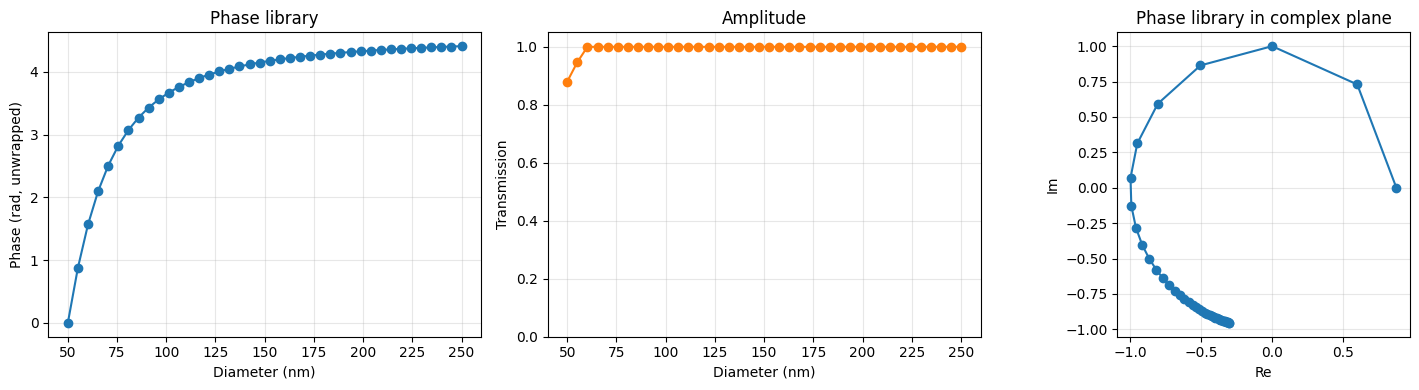

In [6]:
sw = store.get(sweep["handle"]).payload
diam = np.array(sw["diameters_nm"])
amp  = np.array(sw["amplitudes"])
phase = np.unwrap(np.array(sw["phases_rad"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(diam, phase, "o-")
axes[0].set(xlabel="Diameter (nm)", ylabel="Phase (rad, unwrapped)", title="Phase library")
axes[0].grid(alpha=.3)

axes[1].plot(diam, amp, "o-", color="tab:orange")
axes[1].set(xlabel="Diameter (nm)", ylabel="Transmission", title="Amplitude")
axes[1].set_ylim(0, 1.05); axes[1].grid(alpha=.3)

# Plot in the complex plane to see how phase + amplitude trace out the design space
axes[2].plot(amp * np.cos(phase), amp * np.sin(phase), "o-")
axes[2].set_aspect("equal")
axes[2].set(xlabel="Re", ylabel="Im", title="Phase library in complex plane")
axes[2].grid(alpha=.3)
plt.tight_layout()

## 5 · Phase profile generation

For a Fresnel-zone lens at focal length *f*, the required phase is
$\varphi(r) = (2\pi / \lambda)\,(f - \sqrt{f^2 + r^2})$, wrapped to
$[0, 2\pi)$.

In [7]:
mask = tools.get("generate_phase_mask").call_sync({
    "mask_type": "fzl",
    "wavelength_nm": params.wavelength_nm,
    "focal_length_um": params.focal_length_mm * 1e3,
    "diameter_um": params.diameter_mm * 1e3,
    "pixel_size_um": 0.35,
})
phase_mask = store.get(mask["handle"]).payload
print(f"Shape: {phase_mask.shape}, range: "
      f"[{phase_mask.min():.2f}, {phase_mask.max():.2f}] rad")

Shape: (142, 142), range: [0.00, 6.28] rad


### Quantization to N levels

The continuous phase profile is binned, then each bin is mapped to the
meta-atom diameter whose phase response best matches.

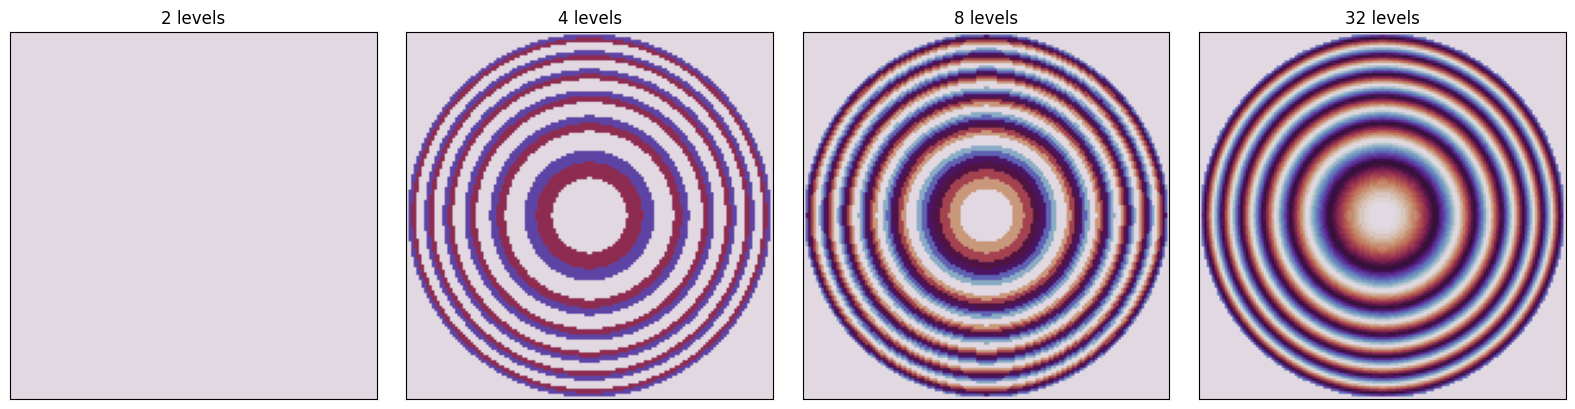

In [8]:
from metaopticsai.phase.quantization import quantize

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n_levels in zip(axes, [2, 4, 8, 32]):
    quantized, bins = quantize(phase_mask, n_levels=n_levels)
    im = ax.imshow(quantized, cmap="twilight")
    ax.set_title(f"{n_levels} levels")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## 6 · Focal-plane analysis

Strehl ratio, FWHM, MTF50 — the headline image-quality numbers.

In [9]:
psf = tools.get("analyze_psf").call_sync({
    "mask_handle": mask["handle"],
    "wavelength_nm": params.wavelength_nm,
    "pixel_size_um": 0.35,
    "focal_length_um": params.focal_length_mm * 1e3,
    "pad_factor": 4,
})
mtf = tools.get("analyze_mtf").call_sync({
    "psf_handle": psf["handle"],
    "pixel_size_um": 0.35,
    "wavelength_nm": params.wavelength_nm,
    "focal_length_um": params.focal_length_mm * 1e3,
})
zer = tools.get("zernike_decompose").call_sync({
    "mask_handle": mask["handle"],
    "n_terms": 15,
})

print(f"Strehl ratio: {psf['strehl_ratio']:.3f}")
print(f"FWHM:         {psf['fwhm_x_um']:.3f} µm")
print(f"MTF50:        {mtf['mtf50_lpmm']:.1f} lp/mm")
print("\nTop aberrations (Noll):")
for t in zer["top_aberrations"]:
    print(f"  Z_{t['noll']:<2} {t['name']:<20} {t['coeff_rad']:+.3f} rad")

Strehl ratio: 0.001
FWHM:         2.681 µm
MTF50:        10.4 lp/mm

Top aberrations (Noll):
  Z_1  Piston               +3.204 rad
  Z_4  Defocus              -0.218 rad
  Z_11 Primary Spherical    +0.079 rad
  Z_14 Secondary Coma (v)   -0.070 rad
  Z_15 Secondary Coma (h)   -0.070 rad


## 7 · (Optional) GDS export

`export_gds` consumes the design + sweep handle and writes a
fabrication-ready GDSII file. **Requires `gdsfactory` installed.**

In [10]:
# Uncomment to actually write a .gds file. Output lands in outputs/.
#
# # First make a 'metalens_design' artifact (in real usage the optimizer makes this).
design_handle = store.put("metalens_design", {"sweep_handle": sweep["handle"], "method": "manual"}, diameter_um=params.diameter_mm * 1e3, focal_length_um=params.focal_length_mm * 1e3)

gds = tools.get("export_gds").call_sync({"design_handle": design_handle, "sweep_handle": sweep["handle"], "output_name": "pipeline_demo", "period_nm": params.periodicity_nm, "pixel_size_um": 0.35, "n_levels": 8,})
print(f"Wrote {gds['path']} ({gds['size_kb']:.1f} KB in {gds['elapsed_s']:.1f}s)")

Wrote D:\metacode\outputs\pipeline_demo.gds (487.9 KB in 0.6s)


## Summary

Every stage in the pipeline returned a *handle* plus a small JSON-safe
summary. The actual numerical artifacts (multi-MB arrays) stay in the
store; LLM agents only ever see the summaries. This is what makes the
same tools usable both interactively (as here) and via MCP.